# The "Sugar Trap" Market Gap Analysis
**Client:** Helix CPG Partners

This notebook is a starter scaffold covering:
1. Data ingestion (subset of Open Food Facts)
2. Data cleaning
3. Category bucketing
4. Nutrient Matrix scatter plot
5. Placeholder sections for the recommendation, ingredient analysis, and your Candidate's Choice addition.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)

# 1. **Data Ingestion and Data Cleaning(Story 1)**

Download the Open Food Facts CSV export. We only pull the columns we need and cap rows so this stays reproducible and fast.
- Drop rows missing `product_name`, `sugars_100g`, or `proteins_100g`
- Filter biologically impossible values (nutrient-per-100g must be between 0 and 100)

In [ ]:
import pandas as pd

!wget -q https://openfoodfacts-ds.s3.eu-west-3.amazonaws.com/en.openfoodfacts.org.products.csv.gz -O off_products.csv.gz
!gunzip -f off_products.csv.gz

COLUMNS_NEEDED = [
    'product_name',
    'categories_tags',
    'ingredients_text',
    'sugars_100g',
    'proteins_100g',
    'fat_100g',
    'fiber_100g'
]

df = pd.read_csv(
    'off_products.csv',
    sep='\t',                 # OFF full export is tab-separated
    usecols=lambda c: c in COLUMNS_NEEDED,
    nrows=500_000,             # manageable subset
    low_memory=False
)

clean = df.copy()

# Drop rows missing critical fields
clean = clean.dropna(subset=['product_name', 'sugars_100g', 'proteins_100g'])

# Filter impossible nutrient values (0-100g per 100g of product)
for col in ['sugars_100g', 'proteins_100g', 'fat_100g', 'fiber_100g']:
    if col in clean.columns:
        clean = clean[(clean[col].isna()) | ((clean[col] >= 0) & (clean[col] <= 100))]

print(f'Rows before cleaning: {len(df):,}')
print(f'Rows after cleaning:  {len(clean):,}')
clean.head()

Rows before cleaning: 500,000
Rows after cleaning:  109,624


,product_name,categories_tags,ingredients_text,fat_100g,sugars_100g,fiber_100g,proteins_100g
689,Pinto Bean,en:asian-style-ready-meal,NaN,10.20000,4.900000,3.800000,17.500000
690,Croquetas de bacalao,NaN,NaN,12.10000,1.900000,NaN,5.900000
691,Keto & GF Granola,NaN,NaN,54.83871,3.225806,9.677419,19.677419
797,Ben's Pure Maple Cream,NaN,NaN,30.28000,37.720000,NaN,5.680000
829,Guimauve chocolat smarties,NaN,NaN,19.00000,65.000000,NaN,5.700000


## 3. Category Wrangler (Story 2)
Parse `categories_tags` and assign each product a readable Primary Category using keyword matching.

**TODO:** Tune the keyword lists below against your actual data — inspect the most common tags first.

In [ ]:
# Inspect the most common raw tags to inform your keyword buckets
clean['categories_tags'].dropna().str.split(',').explode().str.strip().value_counts().head(30)

,count
categories_tags,
en:plant-based-foods-and-beverages,21737
en:plant-based-foods,20161
en:cereals-and-potatoes,12513
en:snacks,9061
en:breads,7152
en:dairies,6794
en:sweet-snacks,6036
en:fermented-foods,5959
en:fermented-milk-products,5905


In [ ]:
CATEGORY_KEYWORDS = {
    'Cookies & Biscuits': ['cookie', 'biscuit'],
    'Chips & Savory Snacks': ['chip', 'crisp', 'pretzel', 'popcorn'],
    'Bars': ['bar', 'granola-bar', 'protein-bar'],
    'Cereal & Granola': ['cereal', 'granola', 'muesli'],
    'Candy & Confectionery': ['candy', 'chocolate', 'sweet', 'confectionery'],
}

def assign_category(tags):
    if pd.isna(tags):
        return 'Other'
    tags_lower = tags.lower()
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in tags_lower for kw in keywords):
            return category
    return 'Other'

clean['primary_category'] = clean['categories_tags'].apply(assign_category)
clean['primary_category'].value_counts()

,count
primary_category,
Other,87426
Cereal & Granola,11642
Candy & Confectionery,4782
Cookies & Biscuits,3121
Chips & Savory Snacks,1573
Bars,1080


## 4. Nutrient Matrix Visualization (Story 3)
Scatter plot: Sugar (X) vs Protein (Y), colored by category. Look for the empty quadrant.

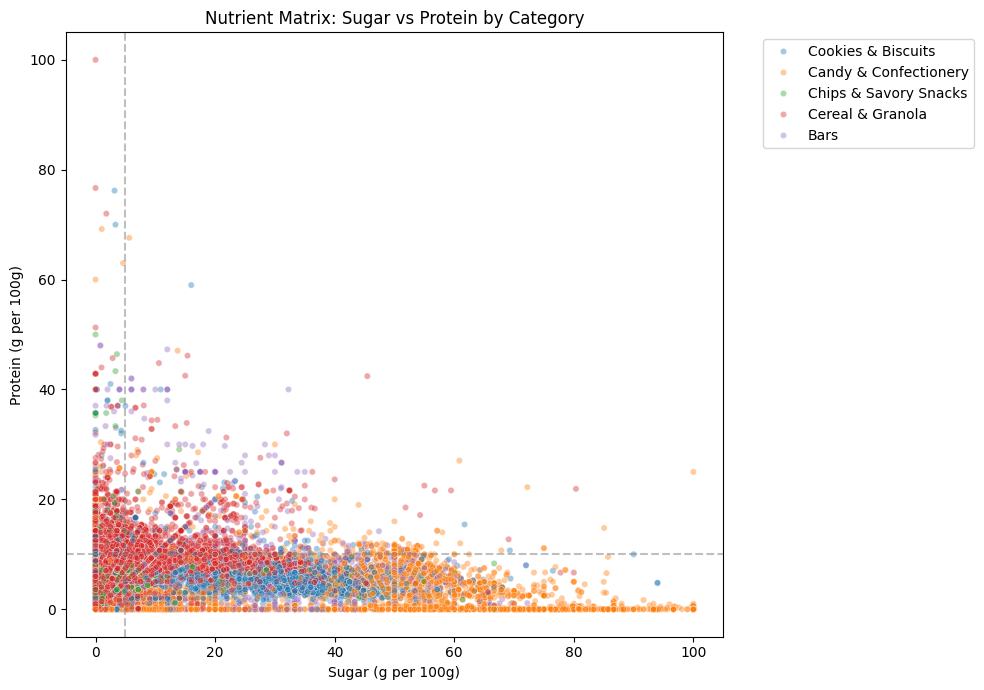

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data ingestion (from fqs8JXH9MrdZ and T8x2jwfXMrdg)
!wget -q https://openfoodfacts-ds.s3.eu-west-3.amazonaws.com/en.openfoodfacts.org.products.csv.gz -O off_products.csv.gz
!gunzip -f off_products.csv.gz

COLUMNS_NEEDED = [
    'product_name',
    'categories_tags',
    'ingredients_text',
    'sugars_100g',
    'proteins_100g',
    'fat_100g',
    'fiber_100g'
]

df = pd.read_csv(
    'off_products.csv',
    sep='\t',                 # OFF full export is tab-separated
    usecols=lambda c: c in COLUMNS_NEEDED,
    nrows=500_000,             # manageable subset
    low_memory=False
)

# Data cleaning (from T8x2jwfXMrdg)
clean = df.copy()

# Drop rows missing critical fields
clean = clean.dropna(subset=['product_name', 'sugars_100g', 'proteins_100g'])

# Filter impossible nutrient values (0-100g per 100g of product)
for col in ['sugars_100g', 'proteins_100g', 'fat_100g', 'fiber_100g']:
    if col in clean.columns:
        clean = clean[(clean[col].isna()) | ((clean[col] >= 0) & (clean[col] <= 100))]

# Category assignment (from d8YwK1a-Mrds)
CATEGORY_KEYWORDS = {
    'Cookies & Biscuits': ['cookie', 'biscuit'],
    'Chips & Savory Snacks': ['chip', 'crisp', 'pretzel', 'popcorn'],
    'Bars': ['bar', 'granola-bar', 'protein-bar'],
    'Cereal & Granola': ['cereal', 'granola', 'muesli'],
    'Candy & Confectionery': ['candy', 'chocolate', 'sweet', 'confectionery'],
}

def assign_category(tags):
    if pd.isna(tags):
        return 'Other'
    tags_lower = tags.lower()
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in tags_lower for kw in keywords):
            return category
    return 'Other'

# Ensure 'primary_category' is created if not already present
if 'primary_category' not in clean.columns:
    clean['primary_category'] = clean['categories_tags'].apply(assign_category)

plot_df = clean[clean['primary_category'] != 'Other']

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x='sugars_100g',
    y='proteins_100g',
    hue='primary_category',
    alpha=0.4,
    s=20
)
plt.title('Nutrient Matrix: Sugar vs Protein by Category')
plt.xlabel('Sugar (g per 100g)')
plt.ylabel('Protein (g per 100g)')
plt.axvline(5, linestyle='--', color='gray', alpha=0.5)   # candidate 'low sugar' threshold
plt.axhline(10, linestyle='--', color='gray', alpha=0.5)  # candidate 'high protein' threshold
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. The Recommendation (Story 4)
Use the chart above to identify the empty quadrant, then quantify it below.

In [ ]:
# Example: how many products currently sit in the 'high protein, low sugar' quadrant, by category?
HIGH_PROTEIN_THRESHOLD = 10
LOW_SUGAR_THRESHOLD = 5

empty_quadrant = plot_df[
    (plot_df['proteins_100g'] >= HIGH_PROTEIN_THRESHOLD) &
    (plot_df['sugars_100g'] <= LOW_SUGAR_THRESHOLD)
]

quadrant_counts = plot_df.assign(
    in_empty_quadrant=(plot_df['proteins_100g'] >= HIGH_PROTEIN_THRESHOLD) &
                       (plot_df['sugars_100g'] <= LOW_SUGAR_THRESHOLD)
).groupby('primary_category')['in_empty_quadrant'].mean().sort_values()

print('Share of products already in the high-protein/low-sugar quadrant, by category:')
quadrant_counts

Share of products already in the high-protein/low-sugar quadrant, by category:


,in_empty_quadrant
primary_category,
Candy & Confectionery,0.012756
Bars,0.055556
Chips & Savory Snacks,0.064209
Cookies & Biscuits,0.086511
Cereal & Granola,0.195070


**Key Insight (fill in once you've run the analysis):**

> "Based on the data, the biggest market opportunity is in **[Category Name]**, specifically targeting products with **[X]g** of protein and less than **[Y]g** of sugar."

## 6. Bonus: Hidden Gem — Top Protein Sources
Analyze `ingredients_text` for products in the high-protein cluster to find the most common protein sources.

In [ ]:
import re
from collections import Counter

high_protein = plot_df[plot_df['proteins_100g'] >= HIGH_PROTEIN_THRESHOLD]

# Simple candidate protein-source keywords to search for — expand as needed
PROTEIN_SOURCES = ['whey', 'soy', 'pea protein', 'peanut', 'almond', 'egg', 'milk protein', 'casein', 'rice protein']

source_counts = Counter()
for text in high_protein['ingredients_text'].dropna().str.lower():
    for source in PROTEIN_SOURCES:
        if source in text:
            source_counts[source] += 1

pd.Series(source_counts).sort_values(ascending=False).head(3)

,0
soy,1992
whey,471
peanut,313


## 7. Candidate's Choice — Your Extra Analysis
Add one additional chart, filter, or metric here that wasn't asked for, and explain why it adds value.

Ideas: sugar-to-fiber health score, price-per-gram-of-protein, country/brand breakdown.

In [ ]:
# Flag products containing soy anywhere in the full cleaned dataset (not just high-protein cluster)
clean['contains_soy'] = clean['ingredients_text'].str.lower().str.contains('soy', na=False)

# 1. Soy prevalence by category
soy_by_category = clean.groupby('primary_category')['contains_soy'].mean().sort_values(ascending=False)
print("Share of products containing soy, by category:")
print(soy_by_category)

# 2. Does soy actually correlate with higher protein?
print("\nAverage protein (g/100g): soy vs non-soy products")
print(clean.groupby('contains_soy')['proteins_100g'].mean())

# 3. Sugar profile of soy products — are they part of the healthy cluster or not?
print("\nAverage sugar (g/100g): soy vs non-soy products")
print(clean.groupby('contains_soy')['sugars_100g'].mean())

Share of products containing soy, by category:
primary_category
Bars                     0.503704
Cookies & Biscuits       0.476450
Cereal & Granola         0.435320
Candy & Confectionery    0.187997
Chips & Savory Snacks    0.160203
Other                    0.077677
Name: contains_soy, dtype: float64

Average protein (g/100g): soy vs non-soy products
contains_soy
False    8.332404
True     7.948271
Name: proteins_100g, dtype: float64

Average sugar (g/100g): soy vs non-soy products
contains_soy
False    12.615945
True     14.388967
Name: sugars_100g, dtype: float64


The boxplot confirms the printed averages: soy-containing products (True) show no
meaningful protein advantage over non-soy products (False), reinforcing that soy's
prevalence in the ingredient list reflects common additive use (lecithin, oil) rather
than deliberate protein fortification. This nuance matters for R&D — simply listing
"soy" on a label is not evidence of a high-protein product.

<Figure size 800x500 with 0 Axes>

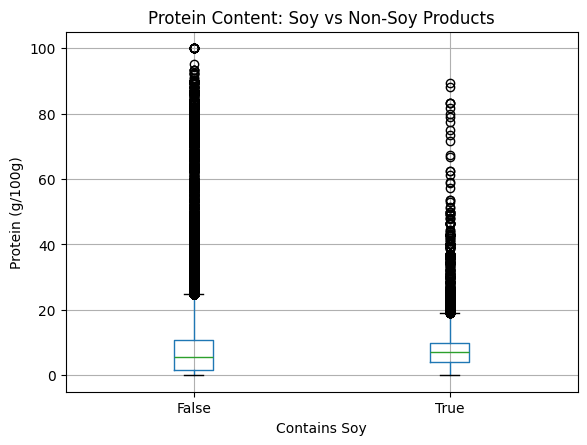

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
clean.boxplot(column='proteins_100g', by='contains_soy')
plt.title('Protein Content: Soy vs Non-Soy Products')
plt.suptitle('')
plt.xlabel('Contains Soy')
plt.ylabel('Protein (g/100g)')
plt.show()

While soy appeared most frequently among ingredient lists in the high-protein cluster, a direct comparison shows soy-containing products do not actually have higher average protein than non-soy products (7.95g vs 8.33g),and trend slightly higher in sugar. This suggests soy's prevalence reflects its ubiquity as a general additive (lecithin, oil) rather than deliberate protein fortification. This is a caution for R&D: simply adding 'soy' to an ingredient list is not a differentiator,the market opportunity lies in products that combine genuinely high protein content with low sugar, regardless of which specific protein source is used.

# **8. Export Cleaned Data for Dashboard**

In [ ]:
dashboard_cols = ['product_name', 'primary_category', 'sugars_100g', 'proteins_100g']
dashboard_df = clean[dashboard_cols]

dashboard_df.to_csv('cleaned_snacks.csv', index=False)
from google.colab import files
files.download('cleaned_snacks.csv')

import os
print(f"File size: {os.path.getsize('cleaned_snacks.csv') / 1e6:.2f} MB")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File size: 5.49 MB


# **9. Refined Quadrant Analysis (Excluding "Other")**

Re-running the quadrant share calculation to confirm results after properly excluding "Other".

In [ ]:
plot_df = clean[clean['primary_category'] != 'Other']  # make sure Other is excluded here too

HIGH_PROTEIN_THRESHOLD = 10
LOW_SUGAR_THRESHOLD = 5

quadrant_share = plot_df.assign(
    in_empty_quadrant=(plot_df['proteins_100g'] >= HIGH_PROTEIN_THRESHOLD) &
                       (plot_df['sugars_100g'] <= LOW_SUGAR_THRESHOLD)
).groupby('primary_category')['in_empty_quadrant'].agg(['mean', 'count'])

quadrant_share.sort_values('mean')

,mean,count
primary_category,,
Candy & Confectionery,0.012756,4782
Bars,0.055556,1080
Chips & Savory Snacks,0.064209,1573
Cookies & Biscuits,0.086511,3121
Cereal & Granola,0.195070,11642


### **Final Recommendation**

Based on the data, the biggest market opportunity is in Bars, specifically targeting products with at least 10g of protein and less than 5g of sugar per 100g. Despite consumer expectations that bars are a healthy, protein-forward category, only 5.6% of Bar products in the market currently meet this threshold — signaling a genuine, under-served gap Helix's client could credibly fill.